# 책소개 copy는 책 판매를 움직이는가?
### 알라딘 SalesPoint × 책소개·장르·길이·가격 — 관계 규명 & 예측

**목표(재정의):** 알라딘 장르 베스트셀러에 *현재 차트인한* 한국 책들 사이에서, **책소개 copy**가
판매 모멘텀 `log10(SalesPoint)`와 얼마나 관련되는지를 — 장르·누적인기(리뷰)·저자·시리즈를 감안한 뒤 —
규명하고 예측한다. 출판사의 "blurb 문구에 얼마나 투자할까" 결정을 돕는 게 목적.

> **정직한 scope 한계:** 표본은 *결과변수(판매)로 선택된* 베스트셀러 차트 책들이라 모집단 대표가 아니다.
> 단일 스냅샷(2026-06-29)·단일 리테일러(알라딘)·SalesPoint=매출 아님(최근가중 모멘텀 지수).
> 관찰 데이터 → 상관, 인과 아님. 모든 copy 계수는 미관측 교란(마케팅비·표지·미디어) 때문에 **상한**.


In [1]:
import pandas as pd, numpy as np, json, warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy import stats as st
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
plt.rcParams.update({"font.family":"AppleGothic","axes.unicode_minus":False,
                     "figure.dpi":120,"savefig.dpi":140,"savefig.bbox":"tight"})
INK="#1f2933"; ACC="#c0392b"; MUT="#9aa5b1"; GRN="#2f7d63"; FIG="report/figures"
ROOT="."  # notebook runs from project root

In [2]:
df = pd.read_csv("data/model_table.csv")
G  = json.load(open("data/feature_groups.json"))
y  = df["y"].values
groups = df["author_main"].fillna("NA").values
CTRL, CTX, T1, T2 = G["control"], G["context"], G["T1_copy"], G["T2_badge"]
len(df), df.shape[1]

(1814, 38)

## 1. 데이터 개요
1,814권 (알라딘 차트인, salesPoint>0, 출간 90일↑). 타깃 `y=log10(SalesPoint)`.
feature 그룹: **T1 copy**(copywriter 통제가능) · **T2 badge**(성취 배지, placebo) · context(장르·가격·길이) · control(리뷰·나이·저자·시리즈).

In [3]:
print("n =", len(df))
print("y = log10(SalesPoint):  mean %.3f  sd %.3f  range [%.2f, %.2f]" % (y.mean(), y.std(), y.min(), y.max()))
print("\nT1 copy :", T1)
print("T2 badge:", T2)
print("context :", CTX)
print("control :", CTRL)

n = 1814
y = log10(SalesPoint):  mean 3.279  sd 0.466  range [2.20, 4.83]

T1 copy : ['has_blurb', 'blurb_len', 'blurb_words', 'n_sentences', 'avg_sent_len', 'exclaim_p100', 'question_p100', 'has_quote', 'has_number_blurb']
T2 badge: ['badge_bestseller', 'badge_rank', 'badge_award', 'badge_million', 'badge_recommend', 'badge_series_word', 'badge_count', 'badge_rate_p100']
context : ['genre_grp', 'log_page', 'log_price', 'is_set', 'is_map']
control : ['log_reviews', 'log_ratingCount', 'has_reviews', 'ratingScore_imp', 'log_age', 'is_series', 'author_freq_log', 'pub_major', 'pub_freq']


## 2. 타깃 분포 — 왜 로그를 쓰는가
SalesPoint 원자료는 heavy right-tail(skew 4.6). 로그 변환하면 near-normal(skew 0.4) → 회귀에 적합.

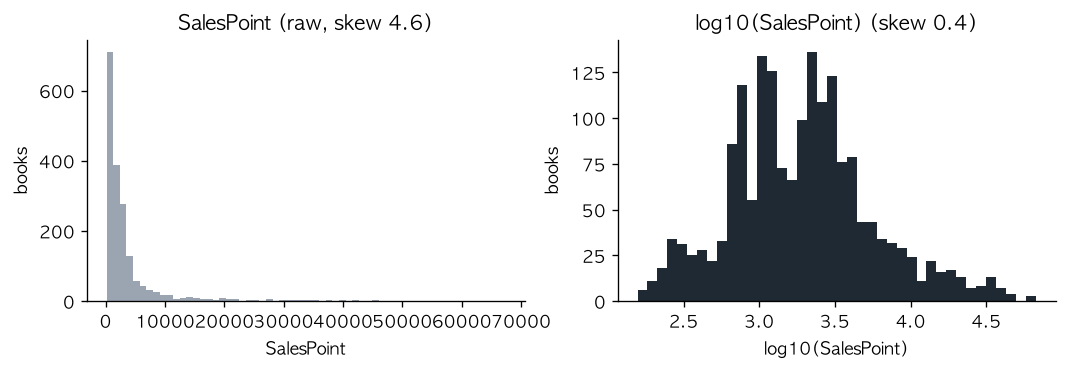

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(df["salesPoint"], bins=60, color=MUT); ax[0].set_title("SalesPoint (raw, skew %.1f)" % st.skew(df["salesPoint"])); ax[0].set_xlabel("SalesPoint")
ax[1].hist(y, bins=40, color=INK); ax[1].set_title("log10(SalesPoint) (skew %.1f)" % st.skew(y)); ax[1].set_xlabel("log10(SalesPoint)")
for a in ax: a.set_ylabel("books"); a.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{FIG}/01_target_dist.png"); plt.show()

## 3. 관계 분석 — de-pooled 중첩 OLS
critic 교훈: lever를 **통째로** 평가하면 genre가 전부 견인해 copy가 0이어도 "통과"한다.
따라서 블록을 분리해 **copy의 *자체* ΔR²**를 본다.
- M0 = controls only → M1 +context(장르/가격/길이) → M2 **+T1 copy** → M3 +T2 badge.
- 합격선: copy 블록 ΔR² ≥ 0.02 (자체).

In [5]:
def dmat(cols, with_genre=True):
    num = [c for c in cols if c != "genre_grp" and df[c].dtype != object]
    parts = [df[num].astype(float)]
    if with_genre and "genre_grp" in cols:
        parts.append(pd.get_dummies(df["genre_grp"], prefix="g", drop_first=True).astype(float))
    return pd.concat(parts, axis=1)

def r2_of(Xdf):
    return sm.OLS(y, sm.add_constant(Xdf, has_constant="add")).fit(cov_type="HC3").rsquared

X_ctrl = dmat(CTRL, with_genre=False)
X_ctx  = pd.concat([X_ctrl, dmat(CTX)], axis=1)
X_t1   = pd.concat([X_ctx, df[T1].astype(float)], axis=1)
X_t2   = pd.concat([X_t1, df[T2].astype(float)], axis=1)
r2c, r2x, r21, r22 = r2_of(X_ctrl), r2_of(X_ctx), r2_of(X_t1), r2_of(X_t2)
print("M0 controls            R²=%.4f" % r2c)
print("M1 +context            R²=%.4f   ΔR²(context)=%+.4f" % (r2x, r2x-r2c))
print("M2 +T1 copy            R²=%.4f   ΔR²(COPY)=%+.4f   <-- bar 0.02" % (r21, r21-r2x))
print("M3 +T2 badge           R²=%.4f   ΔR²(badge placebo)=%+.4f" % (r22, r22-r21))

M0 controls            R²=0.3016
M1 +context            R²=0.5169   ΔR²(context)=+0.2153
M2 +T1 copy            R²=0.5244   ΔR²(COPY)=+0.0075   <-- bar 0.02
M3 +T2 badge           R²=0.5295   ΔR²(badge placebo)=+0.0051


**해석:** context(거의 전부 장르)가 +0.22를 설명한다. **T1 copy는 그 위에 +0.008** — 합격선 0.02의 절반 이하.
T2 badge도 +0.005. 즉 *책소개 텍스트는 판매 모멘텀을 거의 설명하지 못한다.*

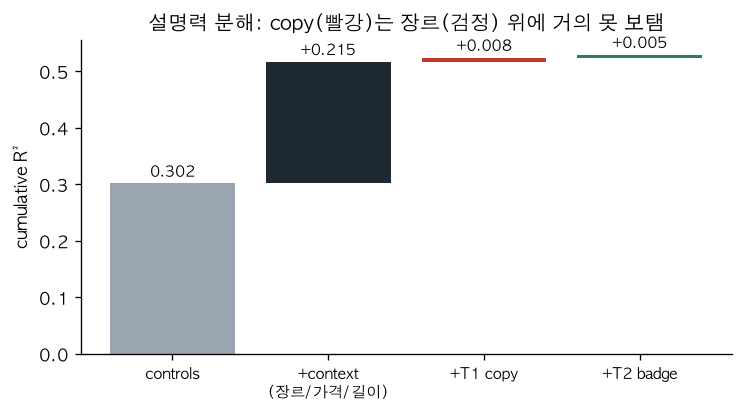

In [6]:
# R² waterfall
labels = ["controls","+context\n(장르/가격/길이)","+T1 copy","+T2 badge"]
vals = [r2c, r2x, r21, r22]; deltas = [r2c, r2x-r2c, r21-r2x, r22-r21]
fig, ax = plt.subplots(figsize=(7,3.4)); base=0
colors=[MUT,INK,ACC,GRN]
for i,(d,c) in enumerate(zip(deltas,colors)):
    ax.bar(i, d, bottom=base, color=c); ax.text(i, base+d+0.012, "%+.3f"%d if i else "%.3f"%d, ha="center", fontsize=9)
    base+=d
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=9); ax.set_ylabel("cumulative R²")
ax.set_title("설명력 분해: copy(빨강)는 장르(검정) 위에 거의 못 보탬"); ax.spines[["top","right"]].set_visible(False)
plt.savefig(f"{FIG}/02_r2_waterfall.png"); plt.show()

## 4. 전체 OLS — 유의성(HC3 + 저자 clustered SE) + BH-FDR
T1·T2 각 블록에서 다중검정(FDR) 보정 후 유의 feature 수와 **IQR당 효과(%)**를 본다.

In [7]:
Xf = sm.add_constant(X_t2, has_constant="add")
mful = sm.OLS(y, Xf).fit(cov_type="HC3")
mclu = sm.OLS(y, Xf).fit(cov_type="cluster", cov_kwds={"groups": groups})
ci = mful.conf_int();
def block(cols, name):
    rows=[]
    for c in cols:
        if c in mful.params.index:
            b=mful.params[c]; p=mful.pvalues[c]; pc=mclu.pvalues[c]
            iqr=df[c].quantile(.75)-df[c].quantile(.25); u=iqr if iqr>0 else 1
            eff=(10**(b*u)-1)*100; lo=(10**(ci.loc[c,0]*u)-1)*100; hi=(10**(ci.loc[c,1]*u)-1)*100
            rows.append([c,b,p,pc,eff,lo,hi])
    rej,q,_,_=multipletests([r[2] for r in rows],alpha=.05,method="fdr_bh")
    out=pd.DataFrame(rows,columns=["feat","beta","p_HC3","p_clu","effIQR%","lo%","hi%"])
    out["q_fdr"]=q; out["sig"]=rej
    out=out.sort_values("p_HC3").reset_index(drop=True)
    print(f"\n[{name}]  significant at FDR q<0.05: {int(rej.sum())}")
    print(out.round(3).to_string(index=False))
    return out
t1tab=block(T1,"T1 copy (actionable)")
t2tab=block(T2,"T2 badge (placebo)")


[T1 copy (actionable)]  significant at FDR q<0.05: 1
            feat   beta  p_HC3  p_clu  effIQR%     lo%    hi%  q_fdr   sig
has_number_blurb  0.051  0.003  0.002   12.474   4.206 21.398  0.023  True
       has_blurb -0.140  0.030  0.037  -27.556 -45.846 -3.087  0.135 False
    exclaim_p100 -0.085  0.143  0.116  -17.834 -36.831  6.875  0.393 False
       has_quote  0.023  0.175  0.177    5.459  -2.331 13.870  0.393 False
     n_sentences  0.020  0.254  0.232    4.708  -3.248 13.319  0.457 False
   question_p100 -0.034  0.348  0.324   -7.553 -21.531  8.914  0.522 False
       blurb_len -0.000  0.737  0.729   -2.590 -16.432 13.545  0.830 False
    avg_sent_len  0.000  0.819  0.812    0.783  -5.724  7.739  0.830 False
     blurb_words  0.001  0.830  0.824    1.607 -12.185 17.565  0.830 False

[T2 badge (placebo)]  significant at FDR q<0.05: 0
             feat   beta  p_HC3  p_clu  effIQR%     lo%    hi%  q_fdr   sig
    badge_million  0.085  0.089  0.075   21.742  -2.923 52.675  0.57

**해석:**
- **T1 copy:** FDR 통과 **1개** = `has_number_blurb`(책소개에 숫자 포함, +12.5%/IQR, Bonferroni·clustered SE에도 강건).
  나머지 8개 무의미. 단 이건 *관찰적* 신호 — "숫자를 넣으면 판다"가 아니라 *숫자가 많은 책 유형*(실용·데이터형)을
  반영할 수 있음. 출간후 예측엔 도움 안 됨(§6b) → **검증할 가설**이지 입증된 lever 아님.
  *(footnote: `has_blurb` b=−0.14는 FDR 미통과·collinearity artifact — blurb 없으면 길이 feature도 전부 0이라 절편 흡수. 해석 안 함.)*
- **T2 badge:** 통제 후 FDR 통과 **0개**. raw로는 "베스트셀러/수상 키워드 책이 2× 더 팔림"처럼 보였지만(§6b 분해),
  이는 주로 **장르 구성 교란**(genre만 통제해도 대부분 소멸) — 키워드가 판매를 *만드는* 게 아니라
  잘 팔리는 장르·책과 *함께 나타날* 뿐. 키워드는 독립 기여 없음.

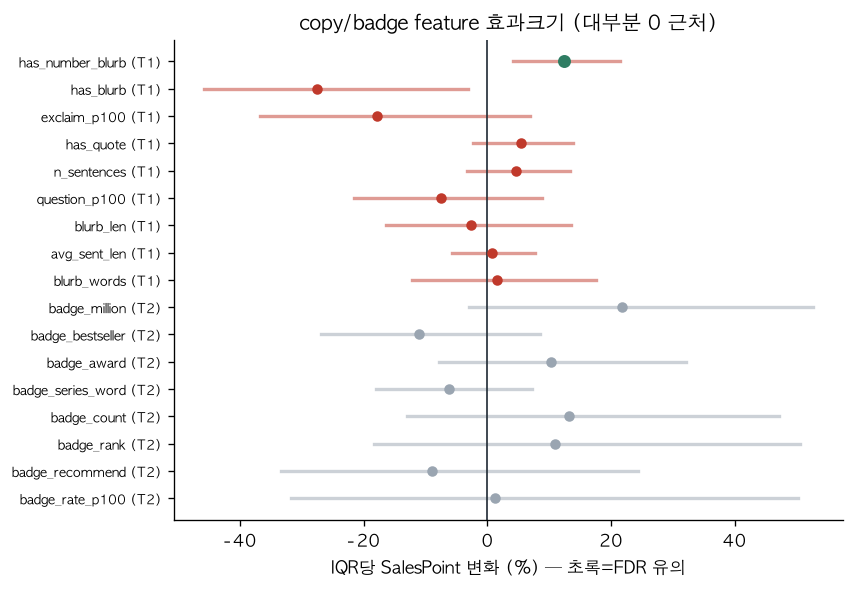

In [8]:
# forest plot: T1 + T2 effect per IQR with 95% CI
tab=pd.concat([t1tab.assign(grp="T1"), t2tab.assign(grp="T2")], ignore_index=True)
tab=tab.iloc[::-1].reset_index(drop=True)
fig, ax=plt.subplots(figsize=(7.2,5.2))
for i,r in tab.iterrows():
    c=ACC if r["grp"]=="T1" else MUT; m="o" if r["sig"] else "o"
    ax.plot([r["lo%"],r["hi%"]],[i,i],color=c,lw=2,alpha=.5)
    ax.scatter(r["effIQR%"],i,color=(GRN if r["sig"] else c),s=46 if r["sig"] else 28,zorder=3)
ax.axvline(0,color=INK,lw=1)
ax.set_yticks(range(len(tab))); ax.set_yticklabels([f'{r.feat} ({r.grp})' for _,r in tab.iterrows()],fontsize=8)
ax.set_xlabel("IQR당 SalesPoint 변화 (%) — 초록=FDR 유의"); ax.set_title("copy/badge feature 효과크기 (대부분 0 근처)")
ax.spines[["top","right"]].set_visible(False)
plt.savefig(f"{FIG}/03_forest.png"); plt.show()

## 5. 강건성 — reviews(mediator) 통제가 copy를 죽인 건 아닌가?
"좋은 copy → 리뷰↑ → 판매↑" 경로를 reviews 통제가 막았을 수 있다. 리뷰 control을 **빼고** copy ΔR²를 재본다.

In [9]:
CTX_only = pd.concat([dmat([c for c in CTX])], axis=1)  # genre/price/page, no review controls
r2_ctx0 = r2_of(CTX_only)
r2_ctx0_t1 = r2_of(pd.concat([CTX_only, df[T1].astype(float)], axis=1))
print("context-only(리뷰 없음)        R²=%.4f" % r2_ctx0)
print("context-only +T1 copy          R²=%.4f   ΔR²(copy, 리뷰통제 X)=%+.4f" % (r2_ctx0_t1, r2_ctx0_t1-r2_ctx0))
print("-> 리뷰를 빼도 copy ΔR²는 여전히 미미. mediator 차단이 원인이 아니라 copy 자체가 약함.")

context-only(리뷰 없음)        R²=0.4097
context-only +T1 copy          R²=0.4184   ΔR²(copy, 리뷰통제 X)=+0.0087
-> 리뷰를 빼도 copy ΔR²는 여전히 미미. mediator 차단이 원인이 아니라 copy 자체가 약함.


## 6. 예측 — 사전런칭 모델(B2)이 장르평균을 이기는가?
GroupKFold(저자 기준, 누수 차단). **B2**=출간 전 알 수 있는 것만(리뷰/평점 제외). baseline=장르평균.
**B1**=리뷰 포함(상한 참고).

In [10]:
gss=GroupShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
tr,te=next(gss.split(df,y,groups)); ytr,yte=y[tr],y[te]; gtr=groups[tr]
def buildX(framing):
    drop={"log_reviews","log_ratingCount","has_reviews","ratingScore_imp"}
    cols=(CTRL+CTX+T1+T2) if framing=="B1" else ([c for c in CTRL if c not in drop]+CTX+T1+T2)
    return dmat(cols).values
def run(framing):
    X=buildX(framing); Xtr,Xte=X[tr],X[te]; gkf=GroupKFold(5)
    cand={"Ridge":Ridge(alpha=1.0),
          "HGB":HistGradientBoostingRegressor(max_depth=3,learning_rate=0.08,max_iter=400,l2_regularization=1.0,random_state=0),
          "RF":RandomForestRegressor(n_estimators=300,max_depth=12,min_samples_leaf=5,n_jobs=-1,random_state=0)}
    cv={}
    for n,m in cand.items():
        sc=[]
        for a,b in gkf.split(Xtr,ytr,gtr):
            if n=="Ridge": s=StandardScaler().fit(Xtr[a]); m.fit(s.transform(Xtr[a]),ytr[a]); pr=m.predict(s.transform(Xtr[b]))
            else: m.fit(Xtr[a],ytr[a]); pr=m.predict(Xtr[b])
            sc.append(r2_score(ytr[b],pr))
        cv[n]=np.mean(sc)
    w=max(cv,key=cv.get); m=cand[w]
    if w=="Ridge": s=StandardScaler().fit(Xtr); m.fit(s.transform(Xtr),ytr); pr=m.predict(s.transform(Xte))
    else: m.fit(Xtr,ytr); pr=m.predict(Xte)
    return cv,w,r2_score(yte,pr),mean_absolute_error(yte,pr)
b0=r2_score(yte,np.full_like(yte,ytr.mean()))
gm=df.iloc[tr].groupby("genre_grp")["y"].mean(); pg=df.iloc[te]["genre_grp"].map(gm).fillna(ytr.mean()).values
b1base=r2_score(yte,pg)
cv1,w1,r2_B1,mae1=run("B1"); cv2,w2,r2_B2,mae2=run("B2")
print("baseline: 전체평균 R²=%.3f | 장르평균 R²=%.3f" % (b0,b1base))
print("B1 (리뷰포함, 상한) winner=%s  TEST R²=%.3f" % (w1,r2_B1))
print("B2 (사전런칭)      winner=%s  TEST R²=%.3f  vs 장르평균 Δ=%+.3f (bar +0.05)" % (w2,r2_B2,r2_B2-b1base))

baseline: 전체평균 R²=-0.004 | 장르평균 R²=0.411
B1 (리뷰포함, 상한) winner=HGB  TEST R²=0.521
B2 (사전런칭)      winner=Ridge  TEST R²=0.423  vs 장르평균 Δ=+0.011 (bar +0.05)


**해석:** 장르평균만으로 R²=0.41. **B2(사전런칭)는 0.42 — 장르평균보다 +0.01뿐.** 즉 출간 전 통제가능 요소
(copy·가격·길이·저자)는 *장르를 아는 것 이상으로* 판매를 거의 못 맞춘다. B1(리뷰 포함)은 0.52 —
리뷰(누적 인기)가 장르 위 +0.10으로 가장 큰 추가 신호지만, 이는 *출간 후* 변수다.

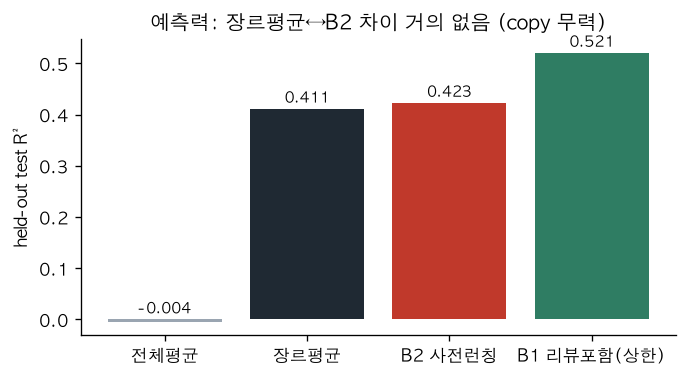

In [11]:
fig,ax=plt.subplots(figsize=(6.4,3.2))
names=["전체평균","장르평균","B2 사전런칭","B1 리뷰포함(상한)"]; vals=[b0,b1base,r2_B2,r2_B1]
cols=[MUT,INK,ACC,GRN]
ax.bar(names,vals,color=cols)
for i,v in enumerate(vals): ax.text(i,max(v,0)+.012,"%.3f"%v,ha="center",fontsize=9)
ax.set_ylabel("held-out test R²"); ax.set_title("예측력: 장르평균↔B2 차이 거의 없음 (copy 무력)")
ax.spines[["top","right"]].set_visible(False); plt.savefig(f"{FIG}/04_prediction.png"); plt.show()

## 6b. 강건성 심화 (critic 반영)
세 가지를 확인한다: ① badge "2× 효과"가 어디서 소멸하나(장르 vs 인기), ② 비선형(HGB)이 copy를 살리나,
③ 예측 결론이 단일 split 운빨인가(20 시드).

In [12]:
# (1) badge "2x" 분해: raw -> 장르만 통제 -> full 통제
gd_only = dmat(["genre_grp"])
r_g      = r2_of(gd_only)
r_g_bad  = r2_of(pd.concat([gd_only, df[T2].astype(float)], axis=1))
r_raw_bad= r2_of(df[T2].astype(float))
r_ctx_bad= r2_of(pd.concat([X_ctx, df[T2].astype(float)], axis=1))  # X_ctx = controls+context
raw_gap = df.groupby(df[[c for c in T2 if c in ['badge_bestseller','badge_award']]].max(axis=1).astype(bool))["y"].mean()
print("raw badge keyword gap: %.3f log10 (~%.1fx)" % (raw_gap.iloc[1]-raw_gap.iloc[0], 10**(raw_gap.iloc[1]-raw_gap.iloc[0])))
print("badge block ΔR²:  raw(절편 위) =%.4f" % r_raw_bad)
print("               장르만 통제 후 =%.4f" % (r_g_bad - r_g))
print("               full 통제 후    =%.4f" % (r_ctx_bad - r2x))
print("badge ↔ log_reviews 상관: bestseller=%.2f award=%.2f (역인과라면 높아야)" %
      (np.corrcoef(df['badge_bestseller'], df['log_reviews'])[0,1],
       np.corrcoef(df['badge_award'], df['log_reviews'])[0,1]))

raw badge keyword gap: 0.305 log10 (~2.0x)
badge block ΔR²:  raw(절편 위) =0.0507
               장르만 통제 후 =0.0122
               full 통제 후    =0.0066
badge ↔ log_reviews 상관: bestseller=0.04 award=0.16 (역인과라면 높아야)


In [13]:
# (2) 비선형이 copy를 살리나? HGB B2: copy 포함 vs 제외 (OOS)
def Xc(with_copy):
    drop={"log_reviews","log_ratingCount","has_reviews","ratingScore_imp"}
    base=[c for c in CTRL if c not in drop]+CTX
    return dmat(base+(T1+T2 if with_copy else [])).values
X1,X0=Xc(True),Xc(False)
def hgb_oos(X):
    m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.08,max_iter=400,l2_regularization=1.0,random_state=0)
    m.fit(X[tr],ytr); return r2_score(yte,m.predict(X[te]))
print("HGB B2  copy 제외 test R²=%.3f" % hgb_oos(X0))
print("HGB B2  copy 포함 test R²=%.3f  -> copy의 OOS marginal=%+.3f (음수면 copy가 예측 해침)" %
      (hgb_oos(X1), hgb_oos(X1)-hgb_oos(X0)))

HGB B2  copy 제외 test R²=0.456


HGB B2  copy 포함 test R²=0.433  -> copy의 OOS marginal=-0.023 (음수면 copy가 예측 해침)


In [14]:
# (3) 다중시드 예측 안정성 (20 seeds): genre-mean vs no-copy vs with-copy
res=[]
for s in range(20):
    a,b=next(GroupShuffleSplit(1,test_size=0.2,random_state=s).split(df,y,groups))
    gm=df.iloc[a].groupby("genre_grp")["y"].mean(); pg=df.iloc[b]["genre_grp"].map(gm).fillna(y[a].mean()).values
    r_gm=r2_score(y[b],pg)
    def rr(X):
        ss=StandardScaler().fit(X[a]); m=Ridge(1.0).fit(ss.transform(X[a]),y[a]); return r2_score(y[b],m.predict(ss.transform(X[b])))
    res.append((r_gm, rr(X0), rr(X1)))
R=np.array(res)
d_nocopy=R[:,1]-R[:,0]; d_copy=R[:,2]-R[:,1]; d_full=R[:,2]-R[:,0]
print("20-seed test R² (mean±sd):  genre-mean %.3f±%.3f | no-copy %.3f±%.3f | with-copy %.3f±%.3f" %
      (R[:,0].mean(),R[:,0].std(),R[:,1].mean(),R[:,1].std(),R[:,2].mean(),R[:,2].std()))
print("Δ(best pre-launch[no-copy] − genre-mean) = %+.3f ± %.3f  (천장, bar +0.05)" % (d_nocopy.mean(),d_nocopy.std()))
print("Δ(copy 추가 marginal)                    = %+.3f ± %.3f  (음수 = copy가 예측 해침)" % (d_copy.mean(),d_copy.std()))
print("Δ(with-copy − genre-mean) ≥ +0.05 인 시드: %d/20" % int((d_full>=0.05).sum()))

20-seed test R² (mean±sd):  genre-mean 0.386±0.043 | no-copy 0.393±0.043 | with-copy 0.400±0.043
Δ(best pre-launch[no-copy] − genre-mean) = +0.007 ± 0.009  (천장, bar +0.05)
Δ(copy 추가 marginal)                    = +0.007 ± 0.011  (음수 = copy가 예측 해침)
Δ(with-copy − genre-mean) ≥ +0.05 인 시드: 0/20


**해석(강건성):**
- **badge 2× 효과는 장르 구성 교란이 주범** — 장르만 통제해도 ΔR² 0.051→0.012로 급감, full 통제 후 ≈0.005.
  badge↔리뷰 상관도 낮음(0.04~0.16) → "이미 인기라 광고"하는 순수 역인과는 아님. *키워드는 잘 팔리는 장르와 동반될 뿐.*
- **비선형도 copy를 못 살림:** HGB에서 copy 추가 시 test R²가 오히려 **하락**(marginal 음수). 선형 ΔR² 미미가 모델 탓 아님.
- **예측 결론은 단일 split 운빨 아님:** 20시드에서 with-copy−genre-mean가 +0.05 bar 도달 **0/20**. 게다가 copy를 빼야
  pre-launch 천장(no-copy)이 가장 높고, **copy를 넣으면 예측이 나빠진다.** → "장르가 거의 전부" 결론 강건.

## 6c. 장르를 아예 통제하면? (장르 안에서 copy)
dummy 통제보다 강하게: ① 장르 fixed-effects(장르 평균 제거, common slope) ② 장르별 separate 회귀(slope도 자유).
주의: 장르당 n≈118에 copy 9개 → 과적합으로 raw ΔR²가 ~0.09 부풀려짐 → **adjusted ΔR²·partial-F**로 봐야 정직.

In [15]:
def numc(cols): return df[[c for c in cols if df[c].dtype!=object]].astype(float)
def demean(fr): return fr.sub(fr.groupby(df["genre_grp"].values).transform("mean"))
# (a) genre fixed-effects (within, common slope)
yd=pd.Series(y).sub(pd.Series(y).groupby(df["genre_grp"].values).transform("mean")).values
Cd=demean(numc(CTRL)); Td=demean(df[T1].astype(float))
def r2d(X): return sm.OLS(yd, sm.add_constant(X,has_constant="add")).fit().rsquared
fe=r2d(pd.concat([Cd,Td],axis=1))-r2d(Cd)
print("(a) 장르 fixed-effects (완전통제, common slope): copy ΔR²(within) = %+.4f" % fe)
# (b) per-genre separate regressions (heterogeneous slopes)
rows=[]
for g,sub in df.groupby("genre_grp"):
    n=len(sub)
    if n<100: continue
    yy=sub["y"].values
    C=sm.add_constant(numc(CTRL).loc[sub.index],has_constant="add")
    CT=sm.add_constant(pd.concat([numc(CTRL).loc[sub.index],sub[T1].astype(float)],axis=1),has_constant="add")
    m0=sm.OLS(yy,C).fit(); m1=sm.OLS(yy,CT).fit(); p=m1.df_model-m0.df_model
    F=((m1.rsquared-m0.rsquared)/p)/((1-m1.rsquared)/(n-CT.shape[1]))
    rows.append((g,n,m1.rsquared-m0.rsquared,m1.rsquared_adj-m0.rsquared_adj,st.f.sf(F,p,n-CT.shape[1])))
wg=pd.DataFrame(rows,columns=["genre","n","dR2_raw","dR2_adj","pF"]).sort_values("dR2_adj",ascending=False)
rej,q,_,_=multipletests(wg["pF"],alpha=.05,method="fdr_bh"); wg["q_fdr"]=q
print("\n(b) per-genre (copy over controls):"); print(wg.round(3).to_string(index=False))
print("\npartial-F p<0.05: %d/%d (우연기대 %.1f) | FDR q<0.05: %d/%d" % ((wg.pF<.05).sum(),len(wg),0.05*len(wg),(q<.05).sum(),len(wg)))
print("copy ΔR² raw median=%.3f (과적합 포함) | adj median=%+.3f (보정)" % (wg.dR2_raw.median(),wg.dR2_adj.median()))

(a) 장르 fixed-effects (완전통제, common slope): copy ΔR²(within) = +0.0124

(b) per-genre (copy over controls):
  genre   n  dR2_raw  dR2_adj    pF  q_fdr
     여행 118    0.127    0.085 0.009  0.117
     과학 118    0.111    0.056 0.068  0.441
    어린이 130    0.083    0.031 0.143  0.579
   자기계발 118    0.082    0.028 0.178  0.579
    인문학 119    0.070    0.011 0.322  0.653
   경제경영 118    0.066    0.010 0.326  0.653
   사회과학 118    0.066    0.007 0.370  0.653
    외국어 118    0.072    0.004 0.402  0.653
  요리/살림 118    0.055   -0.015 0.617  0.840
예술/대중문화 118    0.048   -0.016 0.646  0.840
소설/시/희곡 118    0.017   -0.016 0.829  0.886
  건강/취미 118    0.027   -0.033 0.882  0.886
     역사 118    0.032   -0.041 0.886  0.886

partial-F p<0.05: 1/13 (우연기대 0.7) | FDR q<0.05: 0/13
copy ΔR² raw median=0.066 (과적합 포함) | adj median=+0.007 (보정)


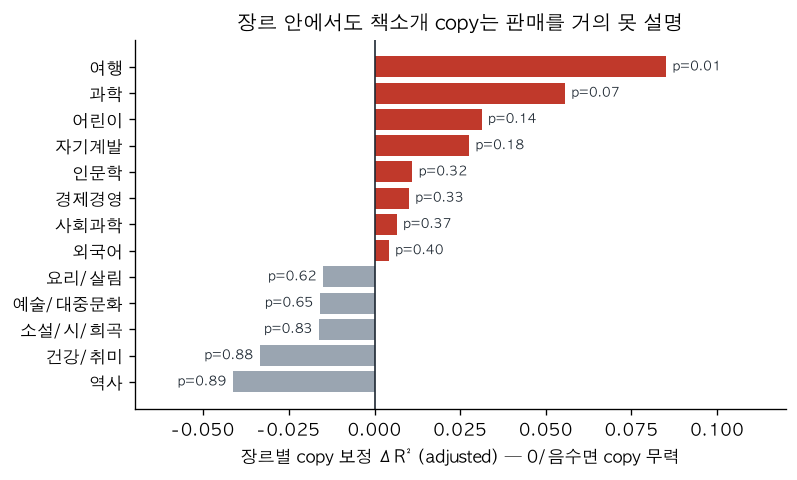

In [16]:
w=wg.sort_values("dR2_adj"); cols=[ACC if v>0 else MUT for v in w["dR2_adj"]]
fig,ax=plt.subplots(figsize=(7,4))
ax.barh(w["genre"],w["dR2_adj"],color=cols); ax.axvline(0,color=INK,lw=1)
for i,(v,p) in enumerate(zip(w["dR2_adj"],w["pF"])):
    ax.text(v+(0.002 if v>=0 else -0.002),i,("p=%.2f"%p),va="center",ha="left" if v>=0 else "right",fontsize=7.5,color=INK)
ax.set_xlabel("장르별 copy 보정 ΔR² (adjusted) — 0/음수면 copy 무력"); ax.set_xlim(-0.07,0.12)
ax.set_title("장르 안에서도 책소개 copy는 판매를 거의 못 설명"); ax.spines[["top","right"]].set_visible(False)
plt.savefig(f"{FIG}/07_within.png"); plt.show()

**해석:** 장르를 *완전히* 통제해도(fixed-effects) copy ΔR²는 +0.012로 여전히 미미. 장르별로 따로 회귀하면
raw ΔR² median이 0.066처럼 커 보이지만 **과적합 inflation**(보정하면 median +0.007, 절반 장르는 음수).
13장르 중 partial-F p<0.05는 **여행 1개뿐**(우연 기대 ~0.7), **FDR 통과 0개**. → 장르 안에서 봐도 결론 동일:
copy는 판매 모멘텀을 거의 못 움직인다. (단 여행 장르만 약한 hint — 단일 장르 A/B 가설로 남김.)

## 7. 판정 — Stage-2 합격선 대비 (MET / NOT MET)

In [17]:
copy_dR2=r21-r2x; n_t1_sig=int(t1tab["sig"].sum())
verdict=pd.DataFrame([
 ["해석축: copy ΔR²","≥ 0.02","%.4f"%copy_dR2,"NOT MET" if copy_dR2<0.02 else "MET"],
 ["해석축: T1 유의 수(FDR)","≥ 3","%d"%n_t1_sig,"NOT MET" if n_t1_sig<3 else "MET"],
 ["예측축: B2 vs 장르평균","≥ +0.05","%+.3f"%(r2_B2-b1base),"NOT MET" if (r2_B2-b1base)<0.05 else "MET"],
], columns=["기준","합격선","달성","판정"])
print(verdict.to_string(index=False))
print("\n총평: 두 축 모두 NOT MET → '책소개 copy/사전통제요소는 판매 모멘텀을 거의 못 움직인다'는 정직한 결과.")
print("badge 키워드 효과는 통제 후 소멸(역인과). 장르·누적인기(리뷰)가 지배.")
verdict.to_csv("data/verdict.csv", index=False)

               기준     합격선     달성      판정
    해석축: copy ΔR²  ≥ 0.02 0.0075 NOT MET
해석축: T1 유의 수(FDR)     ≥ 3      1 NOT MET
  예측축: B2 vs 장르평균 ≥ +0.05 +0.011 NOT MET

총평: 두 축 모두 NOT MET → '책소개 copy/사전통제요소는 판매 모멘텀을 거의 못 움직인다'는 정직한 결과.
badge 키워드 효과는 통제 후 소멸(역인과). 장르·누적인기(리뷰)가 지배.


## 8. 결론 (요약 — 자세한 인사이트·한계는 리포트)
정직하게 *표본 범위 안에서* 진술한다(차트인 한국 책, 단일 스냅샷).

1. **이 표본(이미 차트인한 책)에선 책소개 copy 효과가 감지되지 않는다.** copy 블록 ΔR² **+0.008**, FDR 유의 T1 1개,
   비선형(HGB)으로도 안 살아남(오히려 예측 해침). → 설계상 copy가 가장 중요할 *발견(discovery) 단계*는 표본에서 빠져 있어,
   "copy가 무의미"가 아니라 **"차트 안에서의 위치는 문구로 설명되지 않는다"**가 정확한 진술.
2. **"베스트셀러/수상 키워드 = 판매"는 교란.** raw 2× 격차는 **주로 장르 구성** 때문(통제하면 소멸, badge 독립기여 ≈0).
   키워드가 판매를 만드는 게 아니라 잘 팔리는 장르·책과 동반될 뿐.
3. **장르 + 누적 리뷰(인기)가 지배**(이 표본 기준; 균형설계라 장르 우세 *크기*는 과대 가능). 둘 다 문구 lever 아님.
4. **사전런칭 예측 ≈ 장르평균.** 20시드에서 최선의 출간전 모델도 장르평균 +0.04 이내(0/20이 +0.05 도달), **copy를 넣으면 더 나빠짐.**
   "어떤 장르인가"가 거의 전부. 리뷰(출간후)가 장르 위 최대 추가 신호(+0.10)지만 사전 lever 아님.
5. **검증할 가설 1개:** 책소개에 *구체적 숫자* 포함(+12.5%/IQR, 강건). 단 관찰적·book-type 교란 가능·OOS 도움 안 됨
   → 입증된 lever 아니라 **A/B 테스트할 가설**.

**비즈니스 함의:** 차트 안 책 기준, blurb 문구 미세조정에 과투자할 근거 없음 — 장르 포지셔닝·출간후 리뷰 모멘텀이 핵심.
**한계(결론을 뒤집을 수 있는 것):** 결과변수-선택 표본(discovery margin 제외, copy 효과 축소 가능)·짧은 blurb만·
단일 스냅샷/리테일러·SalesPoint≠매출·미관측 교란(마케팅비·표지·미디어)·관찰적(인과 아님).